In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

In [35]:
df = pd.read_csv("income_evaluation.csv")

In [36]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [37]:
df.shape

(32561, 15)

In [38]:
df.columns

Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='str')

In [39]:
df.columns = df.columns.str.strip()

In [40]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='str')

In [41]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

C:\Users\Dell\AppData\Local\Temp\ipykernel_15272\1126013313.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [13]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [42]:
df.info

<bound method DataFrame.info of        age         workclass  fnlwgt   education  education-num  \
0       39         State-gov   77516   Bachelors             13   
1       50  Self-emp-not-inc   83311   Bachelors             13   
2       38           Private  215646     HS-grad              9   
3       53           Private  234721        11th              7   
4       28           Private  338409   Bachelors             13   
...    ...               ...     ...         ...            ...   
32556   27           Private  257302  Assoc-acdm             12   
32557   40           Private  154374     HS-grad              9   
32558   58           Private  151910     HS-grad              9   
32559   22           Private  201490     HS-grad              9   
32560   52      Self-emp-inc  287927     HS-grad              9   

           marital-status         occupation   relationship   race     sex  \
0           Never-married       Adm-clerical  Not-in-family  White    Male   
1      

In [15]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [43]:
df.describe(include="object")

C:\Users\Dell\AppData\Local\Temp\ipykernel_15272\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [44]:
df.duplicated().sum()

np.int64(24)

In [45]:
df.drop_duplicates(inplace=True)

In [46]:
df.shape

(32537, 15)

In [21]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [47]:
for col in df.columns:
    print(col, (df[col] == "?").sum())

age 0
workclass 1836
fnlwgt 0
education 0
education-num 0
marital-status 0
occupation 1843
relationship 0
race 0
sex 0
capital-gain 0
capital-loss 0
hours-per-week 0
native-country 582
income 0


In [48]:
df.replace("?", np.nan, inplace=True)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [49]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     582
income               0
dtype: int64

In [50]:
for col in ["workclass", "occupation", "native-country"]:
    df[col] = df[col].fillna(df[col].mode()[0])

In [30]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [51]:
df["income"].value_counts()

income
<=50K    24698
>50K      7839
Name: count, dtype: int64

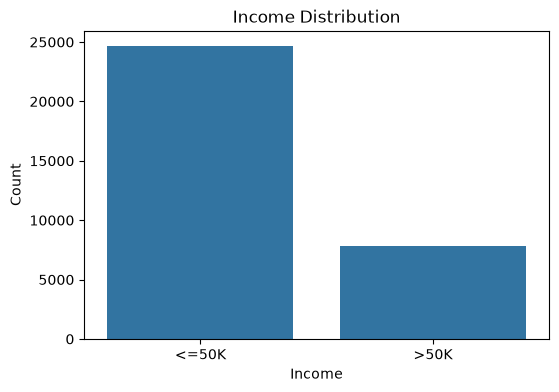

In [52]:
plt.figure(figsize=(6,4))

sns.countplot(x="income", data=df)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()

In [53]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical columns:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


C:\Users\Dell\AppData\Local\Temp\ipykernel_15272\233299197.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


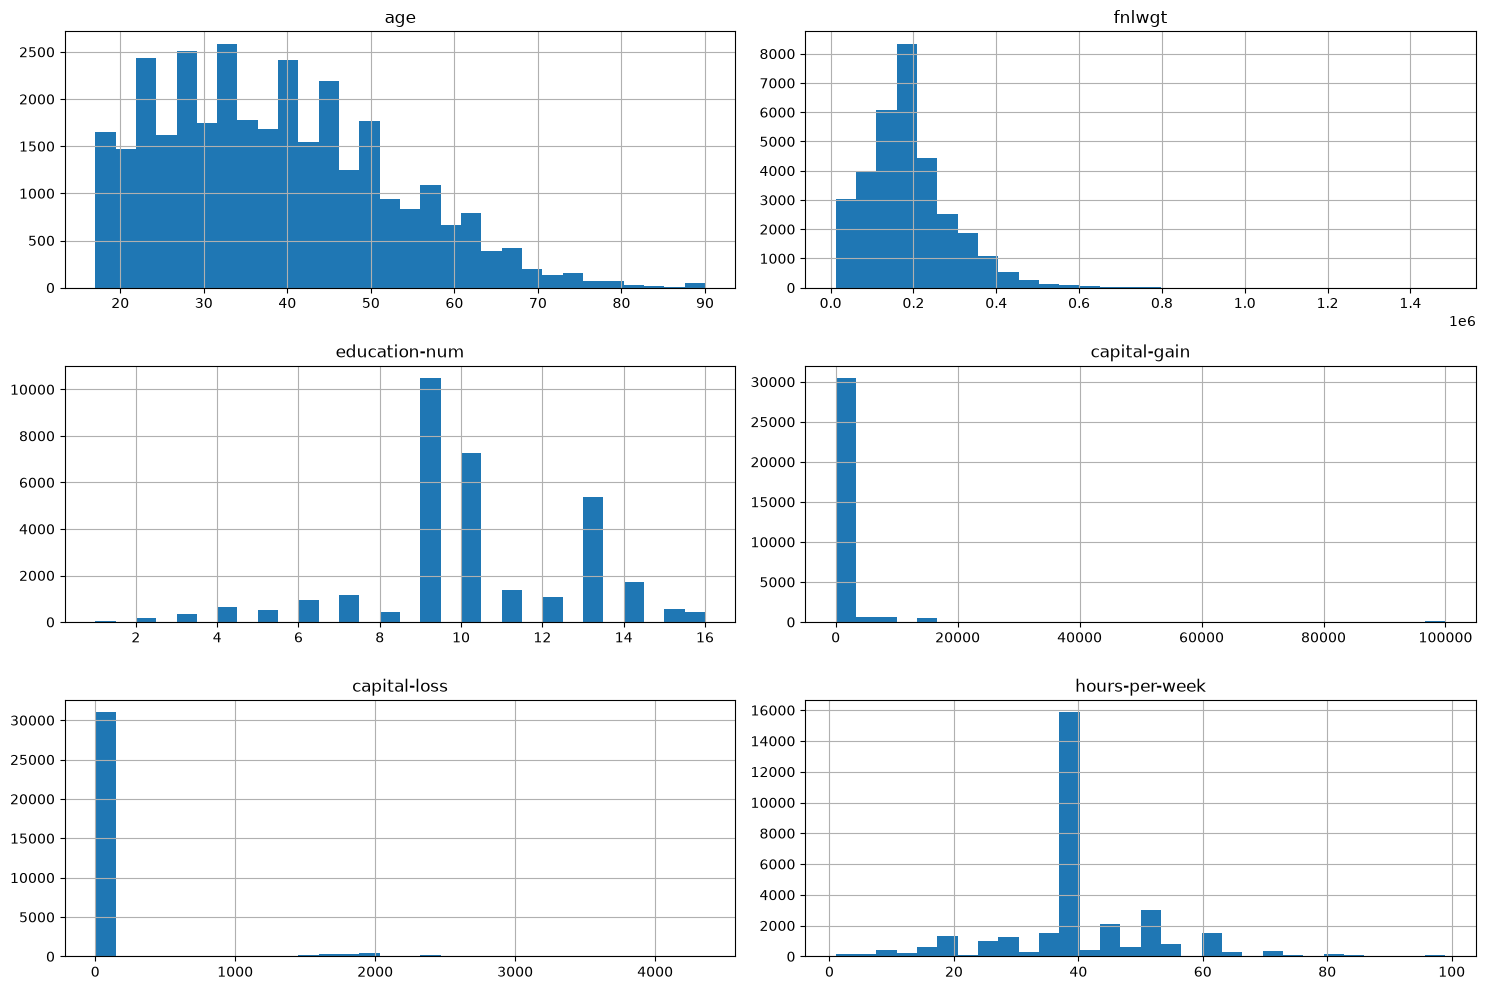

In [54]:
df[numerical_cols].hist(figsize=(15,10), bins=30)

plt.tight_layout()
plt.show()

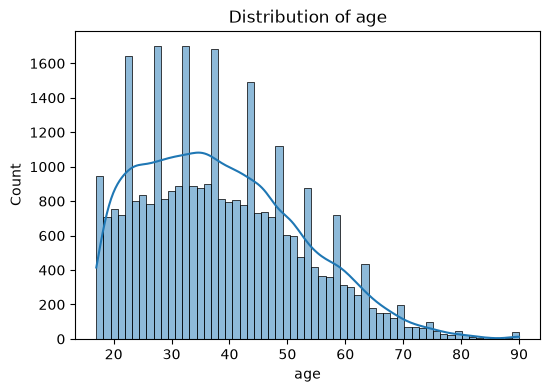

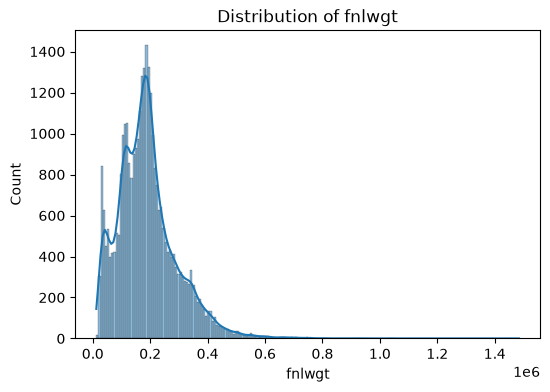

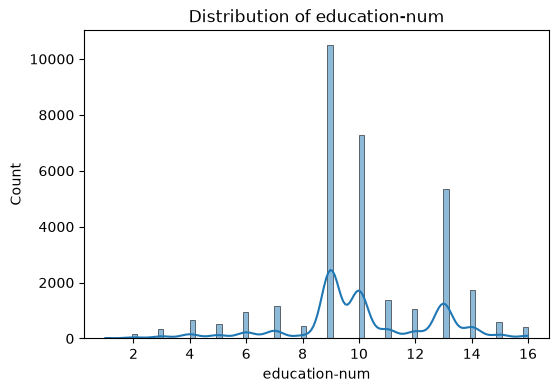

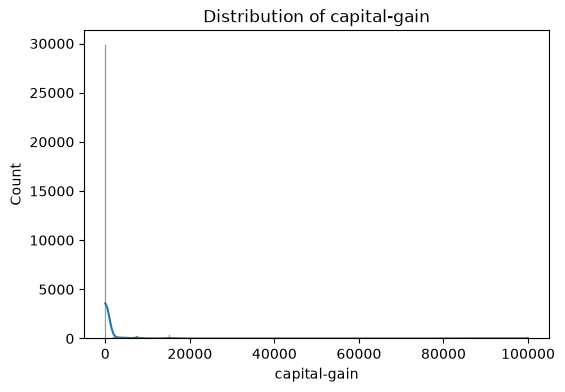

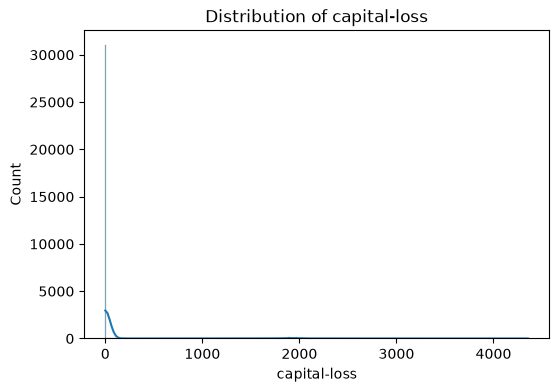

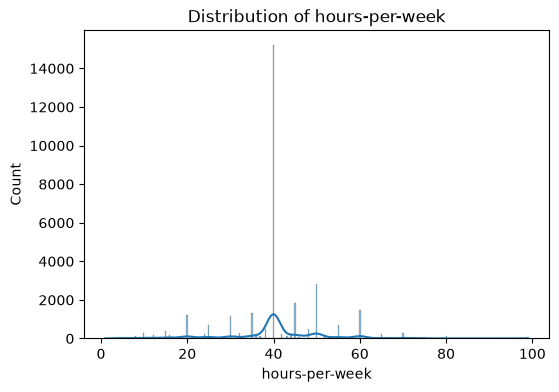

In [55]:
for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

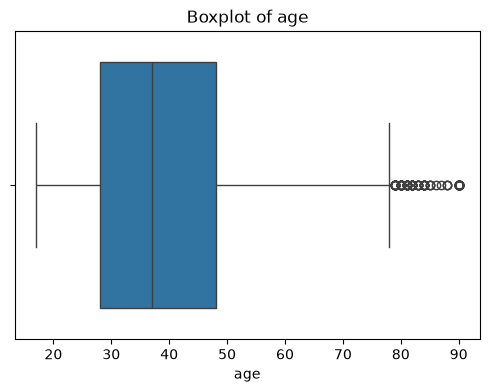

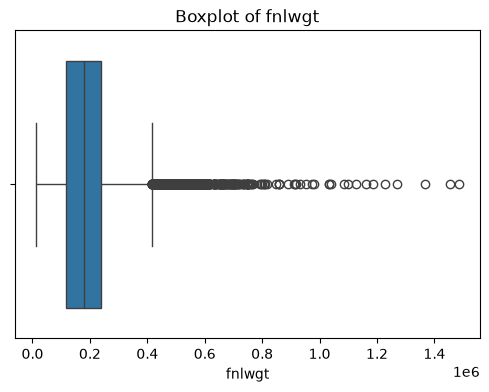

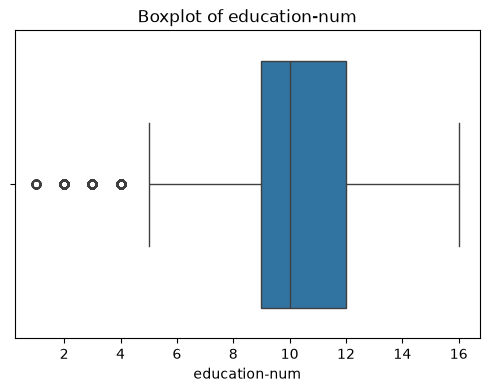

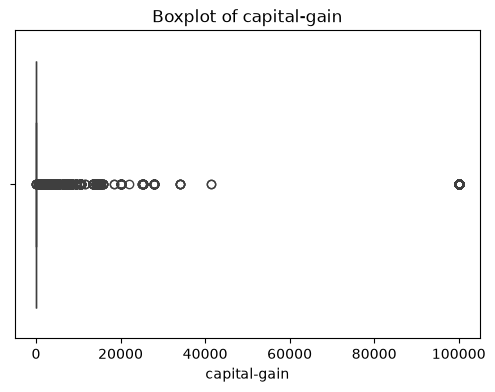

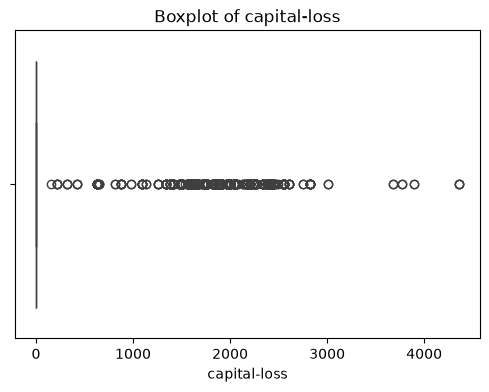

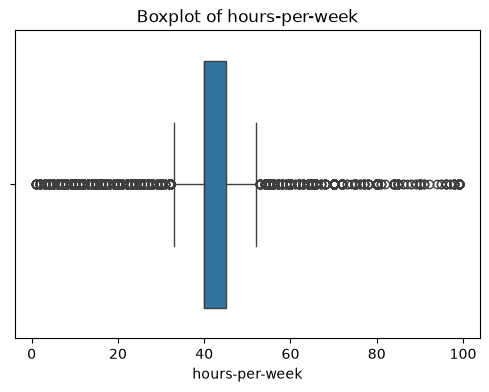

In [56]:
for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

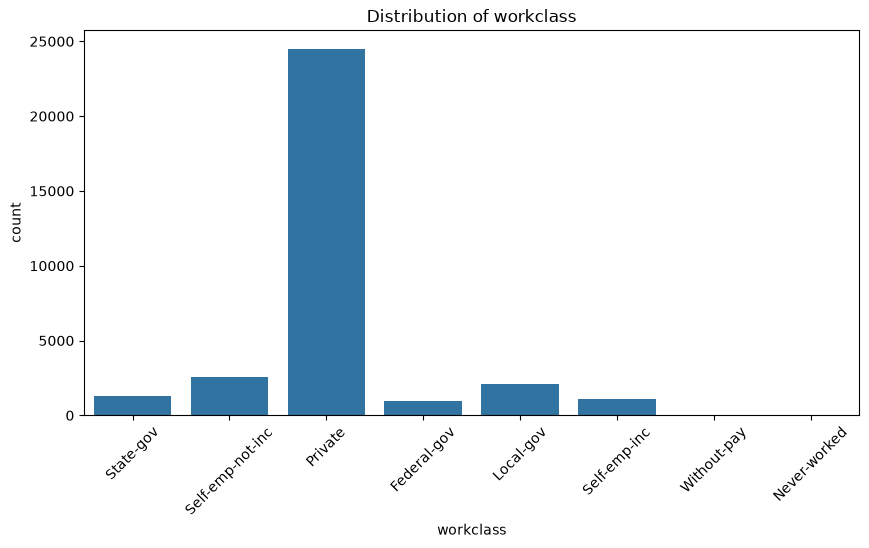

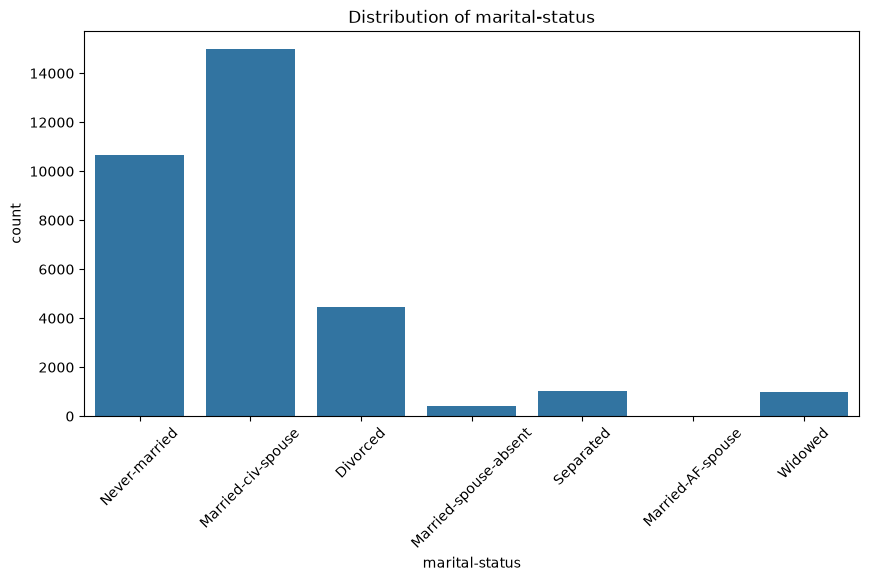

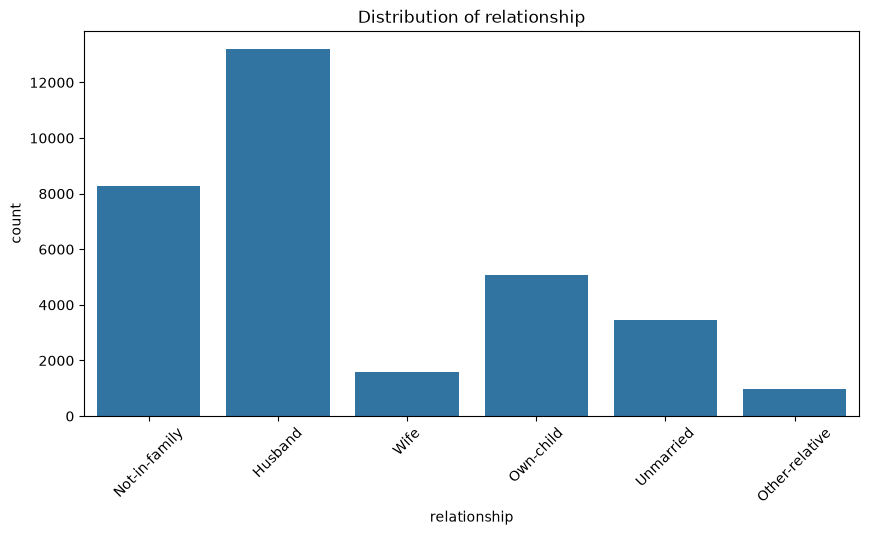

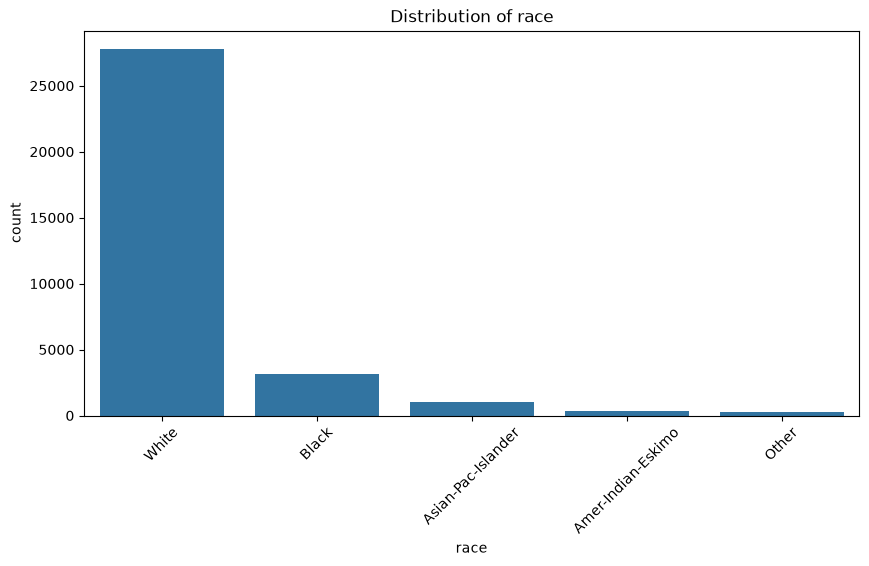

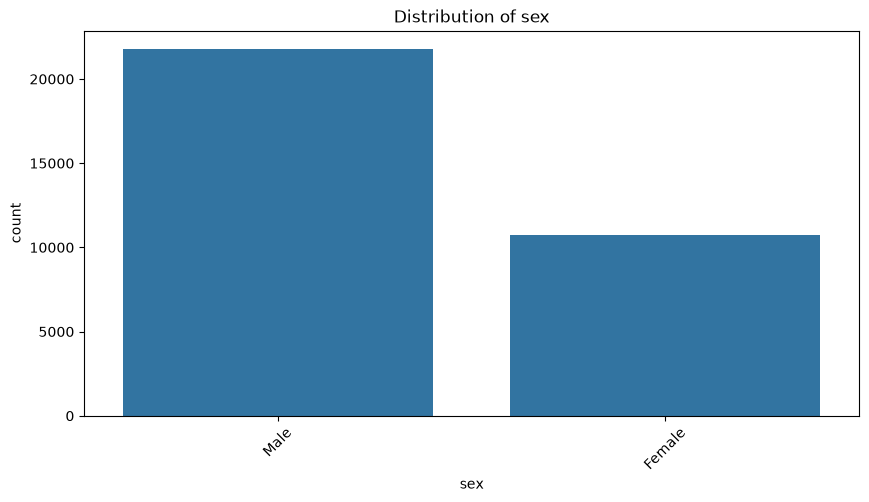

In [57]:
for col in [
    "workclass",
    "marital-status",
    "relationship",
    "race",
    "sex"
]:

    plt.figure(figsize=(10,5))

    sns.countplot(x=col, data=df)

    plt.xticks(rotation=45)

    plt.title(f"Distribution of {col}")

    plt.show()

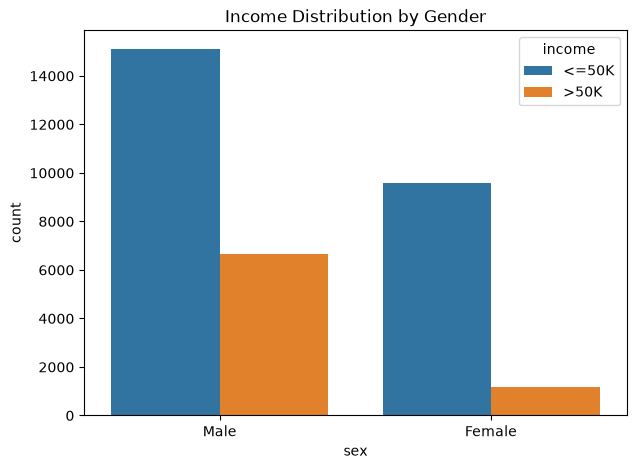

In [58]:
#income vs gender
plt.figure(figsize=(7,5))

sns.countplot(x="sex", hue="income", data=df)

plt.title("Income Distribution by Gender")

plt.show()

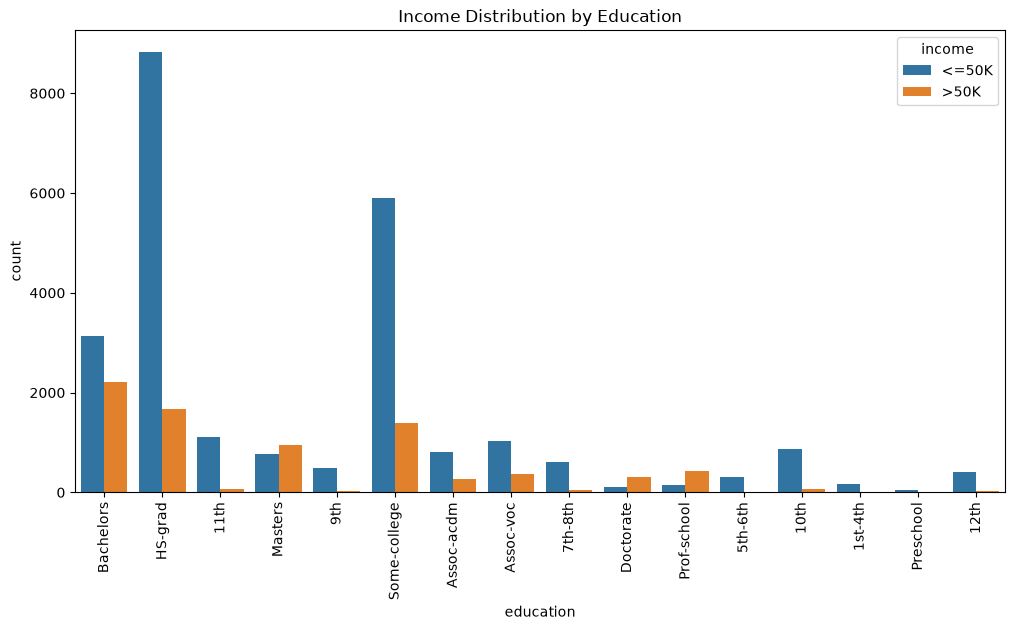

In [59]:
#income vs education
plt.figure(figsize=(12,6))

sns.countplot(
    x="education",
    hue="income",
    data=df
)

plt.xticks(rotation=90)

plt.title("Income Distribution by Education")

plt.show()

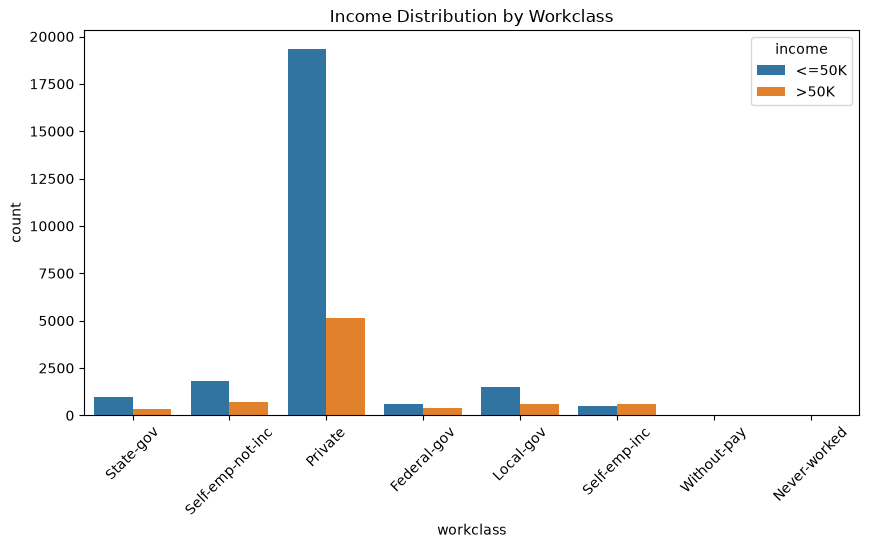

In [60]:
#income vs workclass
plt.figure(figsize=(10,5))

sns.countplot(
    x="workclass",
    hue="income",
    data=df
)

plt.xticks(rotation=45)

plt.title("Income Distribution by Workclass")

plt.show()

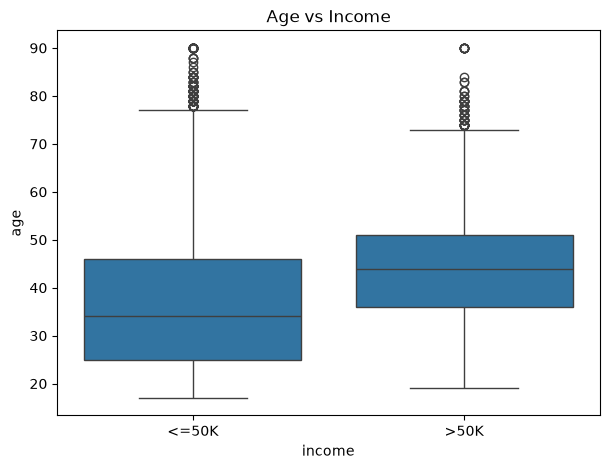

In [61]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="income",
    y="age",
    data=df
)

plt.title("Age vs Income")

plt.show()

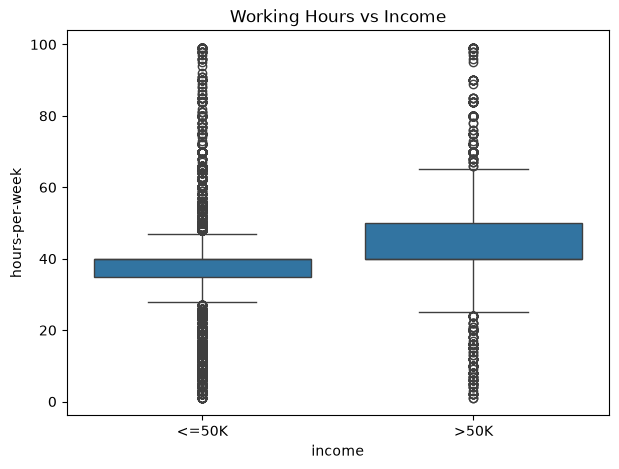

In [62]:
#hours per week vs income
plt.figure(figsize=(7,5))

sns.boxplot(
    x="income",
    y="hours-per-week",
    data=df
)

plt.title("Working Hours vs Income")

plt.show()

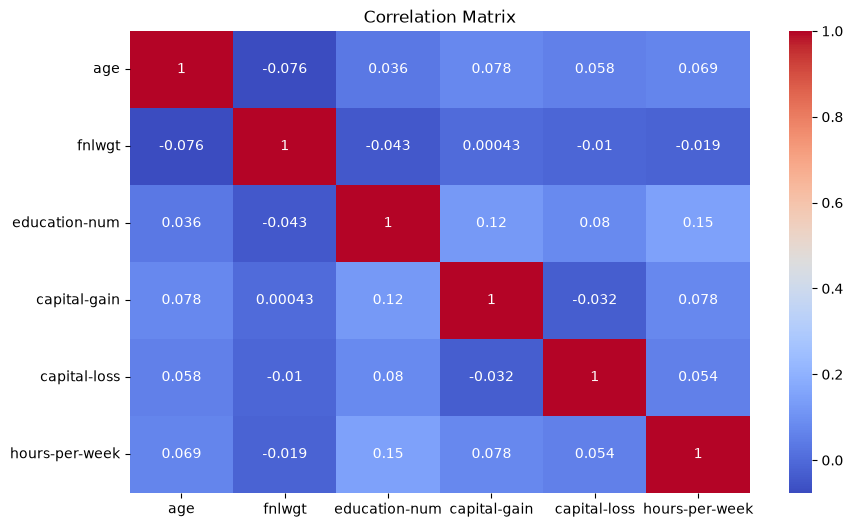

In [63]:
#correlation matrix
plt.figure(figsize=(10,6))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [64]:
#skewness
df[numerical_cols].skew().sort_values(ascending=False)

capital-gain      11.949403
capital-loss       4.592702
fnlwgt             1.447703
age                0.557663
hours-per-week     0.228759
education-num     -0.309500
dtype: float64

In [65]:
#remove skewness
df["capital-gain"] = np.log1p(df["capital-gain"])
df["capital-loss"] = np.log1p(df["capital-loss"])
df["fnlwgt"] = np.log1p(df["fnlwgt"])

In [66]:
df[numerical_cols].skew().sort_values(ascending=False)

capital-loss      4.305701
capital-gain      3.094667
age               0.557663
hours-per-week    0.228759
education-num    -0.309500
fnlwgt           -0.842204
dtype: float64

In [67]:
#check outliers
def check_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return len(outliers)

In [68]:
for col in numerical_cols:

    print(
        col,
        ":",
        check_outliers(df, col)
    )

age : 142
fnlwgt : 1821
education-num : 1193
capital-gain : 2712
capital-loss : 1519
hours-per-week : 9002


In [69]:
def cap_outliers(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    data[column] = data[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

In [70]:
cap_outliers(df, "age")
cap_outliers(df, "fnlwgt")

In [71]:
for col in numerical_cols:
    print(col, ":", check_outliers(df, col))

age : 0
fnlwgt : 0
education-num : 1193
capital-gain : 2712
capital-loss : 1519
hours-per-week : 9002


In [ ]:
#outliers were detected using the IQR method. However, all detected outliers were not removed because some of them represent valid real-world observations.

#- Outliers in age and fnlwgt were capped using IQR bounds.
#- capital-gain and capital-loss were retained after logarithmic transformation because these variables contain a large number of zero values and valid extreme observations.
#- education-num was not treated as an outlier since it is an ordinal/discrete variable.
#- hours-per-week was retained because unusually high or low working hours may be genuine observations and can provide useful information for income classification.

age : 0
fnlwgt : 0
education-num : 1193
capital-gain : 2712
capital-loss : 1519
hours-per-week : 9002


In [73]:
df["income"].value_counts()

income
<=50K    24698
>50K      7839
Name: count, dtype: int64

In [74]:
df["income"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

In [75]:
df["income"].value_counts()

income
0    24698
1     7839
Name: count, dtype: int64

In [76]:
df.drop("education", axis=1, inplace=True)

In [77]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='str')

In [78]:
categorical_cols = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

categorical_cols

['workclass',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country']

In [79]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [80]:
df_encoded.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,11.258253,13,7.684784,0.0,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,11.330348,13,0.000000,0.0,13,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38,12.281398,9,0.000000,0.0,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,53,12.366157,7,0.000000,0.0,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,28,12.732013,13,0.000000,0.0,40,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [81]:
df_encoded.shape

(32537, 83)

In [82]:
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 83 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        32537 non-null  int64  
 1   fnlwgt                                     32537 non-null  float64
 2   education-num                              32537 non-null  int64  
 3   capital-gain                               32537 non-null  float64
 4   capital-loss                               32537 non-null  float64
 5   hours-per-week                             32537 non-null  int64  
 6   income                                     32537 non-null  int64  
 7   workclass_Local-gov                        32537 non-null  int64  
 8   workclass_Never-worked                     32537 non-null  int64  
 9   workclass_Private                          32537 non-null  int64  
 10  workclass_Self-emp-inc                

In [83]:
X = df_encoded.drop("income", axis=1)

y = df_encoded["income"]

In [84]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32537, 82)
y shape: (32537,)


In [85]:
#Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [86]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (26029, 82)
X_test : (6508, 82)
y_train: (26029,)
y_test : (6508,)


In [87]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

income
0    0.759076
1    0.240924
Name: proportion, dtype: float64
income
0    0.759066
1    0.240934
Name: proportion, dtype: float64


In [88]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [91]:
#logistic regression
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [92]:
print("Logistic Regression")

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, lr_pred))

Logistic Regression
Accuracy : 0.8501843884449908
Precision: 0.7234363225320272
Recall   : 0.6122448979591837
F1 Score : 0.6632124352331606

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4940
           1       0.72      0.61      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.80      0.77      0.78      6508
weighted avg       0.84      0.85      0.85      6508



In [102]:
#decision tree
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [103]:
print("Decision Tree")

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, dt_pred))

Decision Tree
Accuracy : 0.8185310387215734
Precision: 0.6230133502860775
Recall   : 0.625
F1 Score : 0.6240050939191341

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4940
           1       0.62      0.62      0.62      1568

    accuracy                           0.82      6508
   macro avg       0.75      0.75      0.75      6508
weighted avg       0.82      0.82      0.82      6508



In [93]:
#random forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [94]:
print("Random Forest")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, rf_pred))

Random Forest
Accuracy : 0.8620159803318992
Precision: 0.750373692077728
Recall   : 0.6403061224489796
F1 Score : 0.690984170681349

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4940
           1       0.75      0.64      0.69      1568

    accuracy                           0.86      6508
   macro avg       0.82      0.79      0.80      6508
weighted avg       0.86      0.86      0.86      6508



In [95]:
#KNN
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

In [96]:
print("KNN")

print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall   :", recall_score(y_test, knn_pred))
print("F1 Score :", f1_score(y_test, knn_pred))

KNN
Accuracy : 0.828518746158574
Precision: 0.6582633053221288
Recall   : 0.5994897959183674
F1 Score : 0.6275033377837116


In [97]:
#SVM
svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

c:\Users\Dell\Downloads\Deployment_unsupervisedML_Assignment_Income_Classification\myenv5\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [98]:
print("SVM")

print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))

SVM
Accuracy : 0.8500307314074985
Precision: 0.7375601926163724
Recall   : 0.5860969387755102
F1 Score : 0.6531627576403696


In [99]:
#XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [100]:
print("XGBoost")

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, xgb_pred))

XGBoost
Accuracy : 0.8756914566687154
Precision: 0.7925983037779492
Recall   : 0.6556122448979592
F1 Score : 0.7176265270506108

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.95      0.92      4940
           1       0.79      0.66      0.72      1568

    accuracy                           0.88      6508
   macro avg       0.84      0.80      0.82      6508
weighted avg       0.87      0.88      0.87      6508



In [104]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, xgb_pred)
    ],

    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, xgb_pred)
    ],

    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, xgb_pred)
    ]
})

results.sort_values(
    "F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
5,XGBoost,0.875691,0.792598,0.655612,0.717627
2,Random Forest,0.862016,0.750374,0.640306,0.690984
0,Logistic Regression,0.850184,0.723436,0.612245,0.663212
4,SVM,0.850031,0.737560,0.586097,0.653163
3,KNN,0.828519,0.658263,0.599490,0.627503
1,Decision Tree,0.818531,0.623013,0.625000,0.624005


In [105]:
#check overfitting
def check_overfitting(model, X_train_data, X_test_data, y_train, y_test):
    
    train_pred = model.predict(X_train_data)
    test_pred = model.predict(X_test_data)
    
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)
    
    return train_accuracy, test_accuracy, train_accuracy - test_accuracy

In [106]:
overfitting_results = []

# Logistic Regression - scaled data
train_acc, test_acc, diff = check_overfitting(
    lr, X_train_scaled, X_test_scaled, y_train, y_test
)

overfitting_results.append([
    "Logistic Regression", train_acc, test_acc, diff
])


# Decision Tree - unscaled data
train_acc, test_acc, diff = check_overfitting(
    dt, X_train, X_test, y_train, y_test
)

overfitting_results.append([
    "Decision Tree", train_acc, test_acc, diff
])


# Random Forest - unscaled data
train_acc, test_acc, diff = check_overfitting(
    rf, X_train, X_test, y_train, y_test
)

overfitting_results.append([
    "Random Forest", train_acc, test_acc, diff
])


# KNN - scaled data
train_acc, test_acc, diff = check_overfitting(
    knn, X_train_scaled, X_test_scaled, y_train, y_test
)

overfitting_results.append([
    "KNN", train_acc, test_acc, diff
])


# SVM - scaled data
train_acc, test_acc, diff = check_overfitting(
    svm, X_train_scaled, X_test_scaled, y_train, y_test
)

overfitting_results.append([
    "SVM", train_acc, test_acc, diff
])


# XGBoost - unscaled data
train_acc, test_acc, diff = check_overfitting(
    xgb, X_train, X_test, y_train, y_test
)

overfitting_results.append([
    "XGBoost", train_acc, test_acc, diff
])

In [107]:
overfitting_df = pd.DataFrame(
    overfitting_results,
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "Difference"
    ]
)

overfitting_df

,Model,Train Accuracy,Test Accuracy,Difference
0,Logistic Regression,0.844059,0.850184,-0.006126
1,Decision Tree,0.999731,0.818531,0.181200
2,Random Forest,0.999731,0.862016,0.137715
3,KNN,0.874909,0.828519,0.046390
4,SVM,0.853202,0.850031,0.003171
5,XGBoost,0.879288,0.875691,0.003597


In [108]:
#Decision Tree and Random Forest are clearly overfitting

In [109]:
#tune decision tree using regularization 
dt_tuned = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_tuned.fit(X_train, y_train)

dt_tuned_pred = dt_tuned.predict(X_test)

In [110]:
dt_train_pred = dt_tuned.predict(X_train)
dt_test_pred = dt_tuned.predict(X_test)

print("Tuned Decision Tree")
print("Train Accuracy:",
      accuracy_score(y_train, dt_train_pred))

print("Test Accuracy:",
      accuracy_score(y_test, dt_test_pred))

print("Difference:",
      accuracy_score(y_train, dt_train_pred)
      - accuracy_score(y_test, dt_test_pred))

Tuned Decision Tree
Train Accuracy: 0.86488147835107
Test Accuracy: 0.8657037492317148
Difference: -0.0008222708806447931


In [111]:
print(classification_report(
    y_test,
    dt_tuned_pred
))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      4940
           1       0.80      0.60      0.68      1568

    accuracy                           0.87      6508
   macro avg       0.84      0.77      0.80      6508
weighted avg       0.86      0.87      0.86      6508



In [112]:
#tune random forest
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

rf_tuned_pred = rf_tuned.predict(X_test)

In [113]:
rf_train_pred = rf_tuned.predict(X_train)
rf_test_pred = rf_tuned.predict(X_test)

print("Tuned Random Forest")
print("Train Accuracy:",
      accuracy_score(y_train, rf_train_pred))

print("Test Accuracy:",
      accuracy_score(y_test, rf_test_pred))

print("Difference:",
      accuracy_score(y_train, rf_train_pred)
      - accuracy_score(y_test, rf_test_pred))

Tuned Random Forest
Train Accuracy: 0.8669945061277805
Test Accuracy: 0.8669330055316533
Difference: 6.150059612719527e-05


In [114]:
print(classification_report(
    y_test,
    rf_tuned_pred
))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      4940
           1       0.81      0.59      0.68      1568

    accuracy                           0.87      6508
   macro avg       0.84      0.77      0.80      6508
weighted avg       0.86      0.87      0.86      6508



In [115]:
#kNN
knn_results = []

for k in [3, 5, 7, 9, 11, 15, 20]:
    
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    
    train_acc = model.score(
        X_train_scaled,
        y_train
    )
    
    test_acc = model.score(
        X_test_scaled,
        y_test
    )
    
    knn_results.append([
        k,
        train_acc,
        test_acc,
        train_acc - test_acc
    ])

knn_results_df = pd.DataFrame(
    knn_results,
    columns=[
        "K",
        "Train Accuracy",
        "Test Accuracy",
        "Difference"
    ]
)

knn_results_df

,K,Train Accuracy,Test Accuracy,Difference
0,3,0.894886,0.823141,0.071746
1,5,0.874909,0.828519,0.046390
2,7,0.867340,0.835126,0.032214
3,9,0.861232,0.832207,0.029025
4,11,0.857313,0.838506,0.018807
5,15,0.851550,0.840965,0.010585
6,20,0.847516,0.839582,0.007934


In [116]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Decision Tree",
        "Tuned Random Forest",
        "KNN",
        "SVM",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_tuned_pred),
        accuracy_score(y_test, rf_tuned_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_tuned_pred),
        precision_score(y_test, rf_tuned_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, xgb_pred)
    ],

    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_tuned_pred),
        recall_score(y_test, rf_tuned_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, xgb_pred)
    ],

    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_tuned_pred),
        f1_score(y_test, rf_tuned_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, xgb_pred)
    ]
})

final_results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
5,XGBoost,0.875691,0.792598,0.655612,0.717627
1,Tuned Decision Tree,0.865704,0.795571,0.595663,0.681255
2,Tuned Random Forest,0.866933,0.809524,0.585459,0.679497
0,Logistic Regression,0.850184,0.723436,0.612245,0.663212
4,SVM,0.850031,0.737560,0.586097,0.653163
3,KNN,0.828519,0.658263,0.599490,0.627503


After comparing Logistic Regression, Decision Tree, Random Forest, KNN, SVM, and XGBoost, XGBoost achieved the best overall performance. It obtained an accuracy of 87.57%, precision of 79.26%, recall of 65.56%, and F1-score of 71.76%.

Decision Tree and Random Forest initially showed significant overfitting. After hyperparameter tuning, their train-test gaps were substantially reduced and their generalization improved. However, XGBoost continued to provide the best overall test performance while maintaining a very small train-test accuracy gap.

Therefore, XGBoost was selected as the final model for income classification.

In [117]:
import joblib
joblib.dump(xgb, "xgboost_income_model.pkl")
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']